In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Font setting
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================================
# Data Preparation
# ============================================================================

# Test Results
test_results = {
    'Brute Force': {'Recall': 0.9587, 'FPR': 0.0057, 'Precision': 0.9721, 'F1': 0.9653,
                    'TP': 557, 'FP': 16, 'FN': 24, 'TN': 2811},
    'Botnet': {'Recall': 0.0000, 'FPR': 0.0407, 'Precision': 0.0000, 'F1': 0.0000,
               'TP': 0, 'FP': 115, 'FN': 332, 'TN': 2712},
    'DoS/DDoS': {'Recall': 0.5754, 'FPR': 0.0534, 'Precision': 0.8859, 'F1': 0.6976,
                 'TP': 1172, 'FP': 151, 'FN': 865, 'TN': 2676},
    'Web Attack': {'Recall': 0.2595, 'FPR': 0.0088, 'Precision': 0.6575, 'F1': 0.3721,
                   'TP': 48, 'FP': 25, 'FN': 137, 'TN': 2802}
}

# FPR Limits (α)
alpha_limits = {
    'Brute Force': 0.01,
    'Botnet': 0.05,
    'DoS/DDoS': 0.10,
    'Web Attack': 0.01
}

categories = ['Brute Force', 'DoS/DDoS', 'Web Attack', 'Botnet']


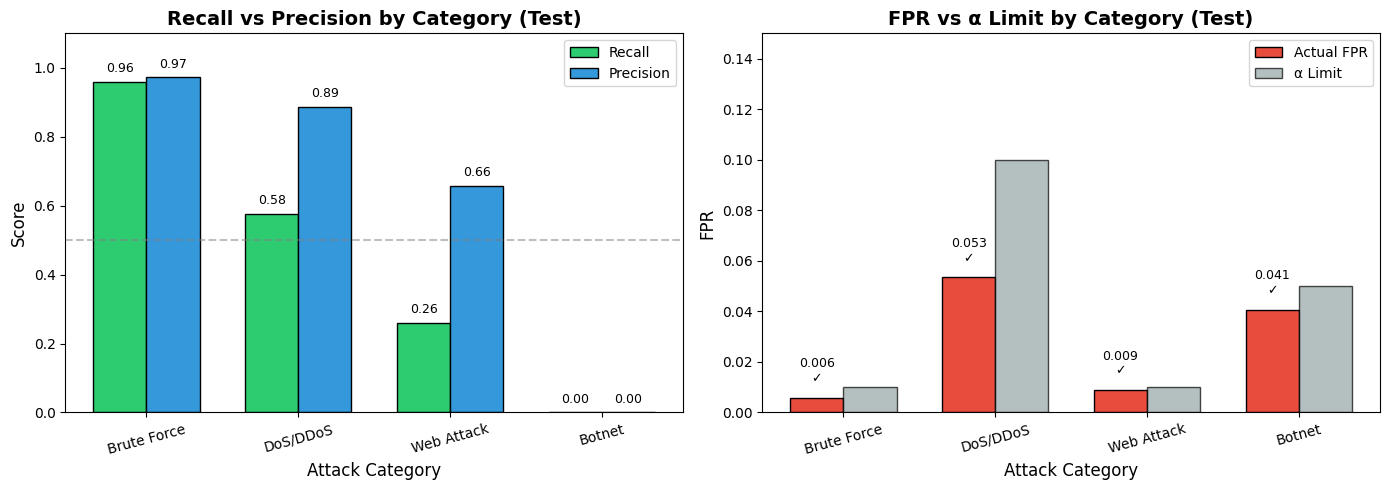

Saved: 01_performance_bar_chart.png


In [2]:
# 1. Performance Bar Chart by Category
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1-1. Recall & Precision Comparison
x = np.arange(len(categories))
width = 0.35

recalls = [test_results[cat]['Recall'] for cat in categories]
precisions = [test_results[cat]['Precision'] for cat in categories]

bars1 = axes[0].bar(x - width/2, recalls, width, label='Recall', color='#2ecc71', edgecolor='black')
bars2 = axes[0].bar(x + width/2, precisions, width, label='Precision', color='#3498db', edgecolor='black')

axes[0].set_xlabel('Attack Category', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Recall vs Precision by Category (Test)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=15)
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='upper right')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Value labels
for bar, val in zip(bars1, recalls):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, precisions):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 1-2. FPR & α Limit Comparison
fprs = [test_results[cat]['FPR'] for cat in categories]
alphas = [alpha_limits[cat] for cat in categories]

bars3 = axes[1].bar(x - width/2, fprs, width, label='Actual FPR', color='#e74c3c', edgecolor='black')
bars4 = axes[1].bar(x + width/2, alphas, width, label='α Limit', color='#95a5a6', edgecolor='black', alpha=0.7)

axes[1].set_xlabel('Attack Category', fontsize=12)
axes[1].set_ylabel('FPR', fontsize=12)
axes[1].set_title('FPR vs α Limit by Category (Test)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=15)
axes[1].set_ylim(0, 0.15)
axes[1].legend(loc='upper right')

# Value labels + PASS/FAIL
for i, (bar, fpr, alpha) in enumerate(zip(bars3, fprs, alphas)):
    status = '✓' if fpr <= alpha else '✗'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{fpr:.3f}\n{status}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('01_performance_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_performance_bar_chart.png")


```test
Recall vs Precision

This chart highlights that high precision alone does not guarantee effective detection. Under strict FPR constraints, recall becomes the dominant performance indicator


FPR vs α Limit Bar Chart
All attack categories satisfy the predefined FPR constraints, confirming that false positives were effectively controlled by design
```

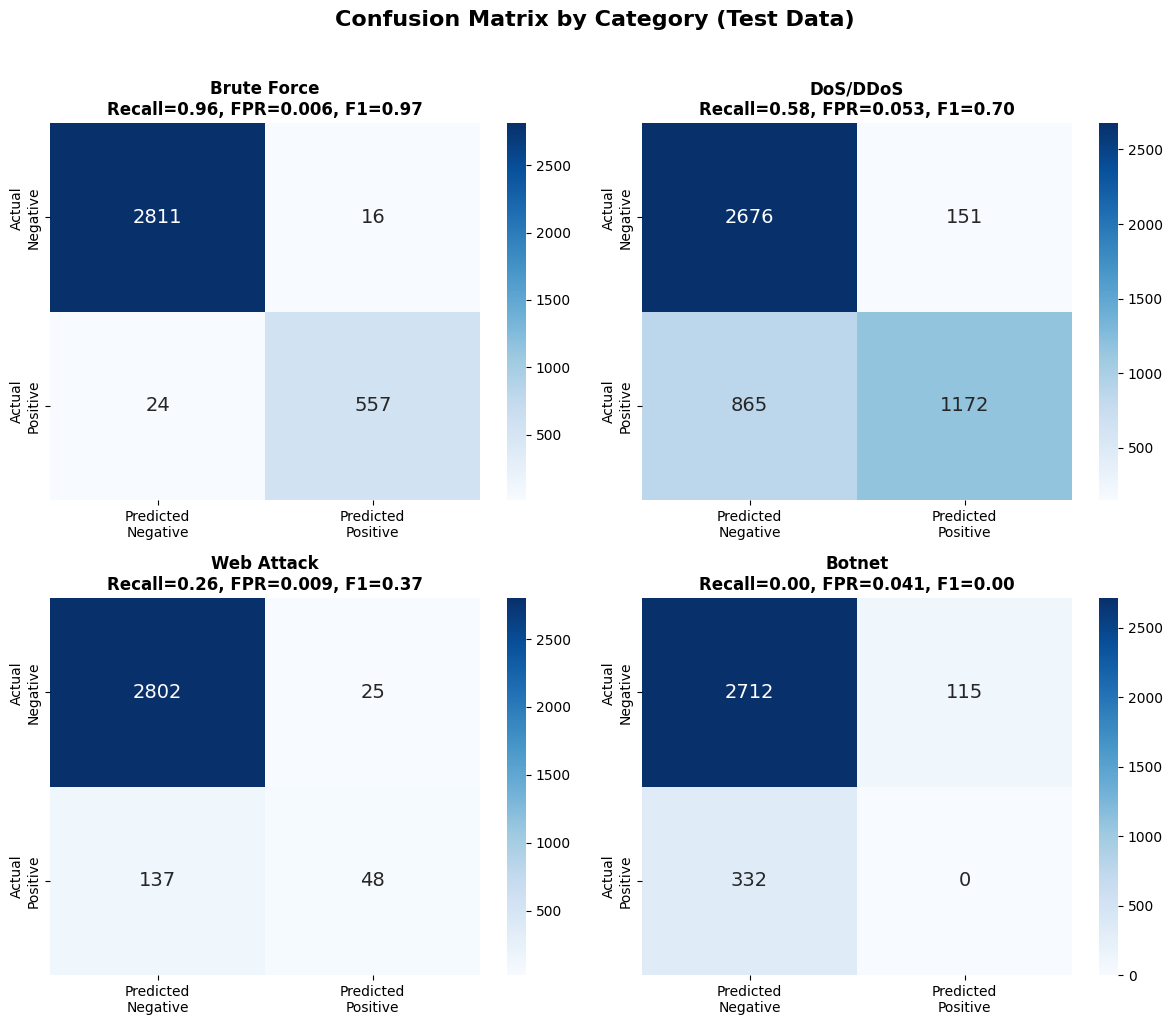

Saved: 02_confusion_matrix.png


In [3]:
# 2. Confusion Matrix (4 Categories)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, cat in enumerate(categories):
    r = test_results[cat]
    
    # Confusion Matrix data
    cm = np.array([[r['TN'], r['FP']], 
                   [r['FN'], r['TP']]])
    
    # Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Predicted\nNegative', 'Predicted\nPositive'],
                yticklabels=['Actual\nNegative', 'Actual\nPositive'],
                annot_kws={'size': 14})
    
    # Title with metrics
    title = f'{cat}\nRecall={r["Recall"]:.2f}, FPR={r["FPR"]:.3f}, F1={r["F1"]:.2f}'
    axes[idx].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix by Category (Test Data)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_confusion_matrix.png")



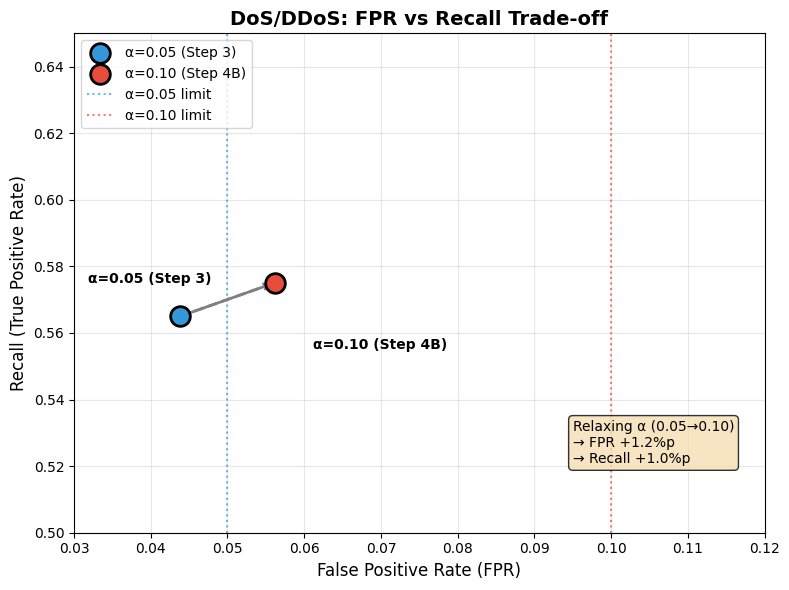

Saved: 03_dos_tradeoff.png


In [6]:
# 3. DoS/DDoS Trade-off Visualization
# ============================================================================

# DoS/DDoS performance by α (Step 3, Step 4B results)
dos_tradeoff = {
    'alpha': [0.05, 0.10],
    'FPR': [0.0438, 0.0562],
    'Recall': [0.5650, 0.5751],
    'label': ['α=0.05 (Step 3)', 'α=0.10 (Step 4B)']
}

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
colors = ['#3498db', '#e74c3c']
for i in range(len(dos_tradeoff['alpha'])):
    ax.scatter(dos_tradeoff['FPR'][i], dos_tradeoff['Recall'][i], 
               s=200, c=colors[i], edgecolor='black', linewidth=2, zorder=5,
               label=dos_tradeoff['label'][i])
    
    # Label annotation
    offset = (-0.012, 0.01) if i == 0 else (0.005, -0.02)
    ax.annotate(dos_tradeoff['label'][i], 
                (dos_tradeoff['FPR'][i], dos_tradeoff['Recall'][i]),
                xytext=(dos_tradeoff['FPR'][i] + offset[0], dos_tradeoff['Recall'][i] + offset[1]),
                fontsize=10, fontweight='bold')

# Connection line
ax.plot(dos_tradeoff['FPR'], dos_tradeoff['Recall'], 
        'k--', alpha=0.5, linewidth=2, zorder=1)

# α limit lines
ax.axvline(x=0.05, color='#3498db', linestyle=':', alpha=0.7, label='α=0.05 limit')
ax.axvline(x=0.10, color='#e74c3c', linestyle=':', alpha=0.7, label='α=0.10 limit')

# Arrow for direction
ax.annotate('', xy=(dos_tradeoff['FPR'][1], dos_tradeoff['Recall'][1]),
            xytext=(dos_tradeoff['FPR'][0], dos_tradeoff['Recall'][0]),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('Recall (True Positive Rate)', fontsize=12)
ax.set_title('DoS/DDoS: FPR vs Recall Trade-off', fontsize=14, fontweight='bold')
ax.set_xlim(0.03, 0.12)
ax.set_ylim(0.50, 0.65)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# Text box with explanation
textstr = 'Relaxing α (0.05→0.10)\n→ FPR +1.2%p\n→ Recall +1.0%p'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.095, 0.52, textstr, fontsize=10, verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.savefig('03_dos_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_dos_tradeoff.png")



This visualization shows that relaxing the FPR constraint yields diminishing returns for DoS/DDoS detection, confirming performance saturation

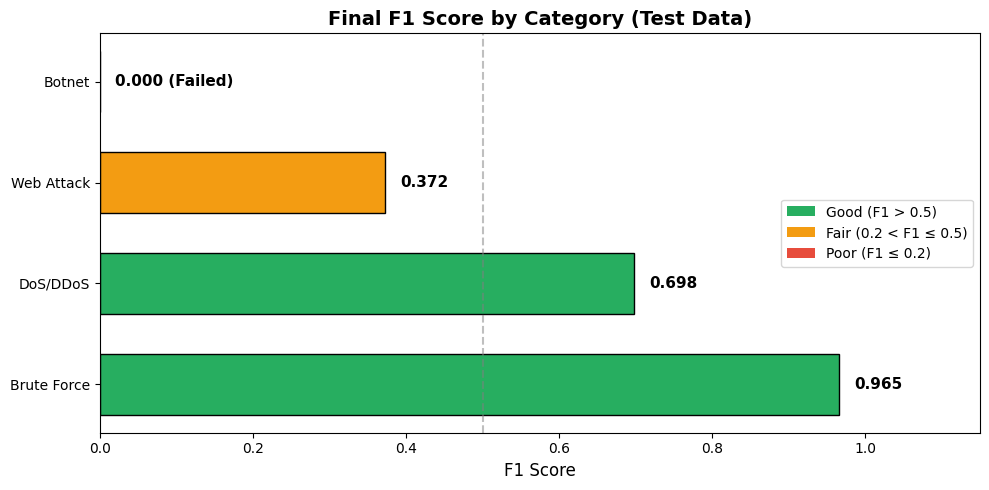

Saved: 04_f1_summary.png

All visualizations saved!
1. 01_performance_bar_chart.png
2. 02_confusion_matrix.png
3. 03_dos_tradeoff.png
4. 04_f1_summary.png


In [8]:
# 4. F1 Score Summary Chart
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

f1_scores = [test_results[cat]['F1'] for cat in categories]
colors = ['#27ae60' if f1 > 0.5 else '#f39c12' if f1 > 0.2 else '#e74c3c' for f1 in f1_scores]

bars = ax.barh(categories, f1_scores, color=colors, edgecolor='black', height=0.6)

# Value labels
for bar, f1, cat in zip(bars, f1_scores, categories):
    label = f'{f1:.3f}'
    if cat == 'Botnet':
        label += ' (Failed)'
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
            label, ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Final F1 Score by Category (Test Data)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='F1=0.5 baseline')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', label='Good (F1 > 0.5)'),
                   Patch(facecolor='#f39c12', label='Fair (0.2 < F1 ≤ 0.5)'),
                   Patch(facecolor='#e74c3c', label='Poor (F1 ≤ 0.2)')]
ax.legend(handles=legend_elements, loc='center right')

plt.tight_layout()
plt.savefig('04_f1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_f1_summary.png")


print("\n" + "="*50)
print("All visualizations saved!")
print("="*50)
print("1. 01_performance_bar_chart.png")
print("2. 02_confusion_matrix.png")
print("3. 03_dos_tradeoff.png")
print("4. 04_f1_summary.png")


F1 scores vary significantly by attack type, reflecting intrinsic differences in separability rather than tuning quality. All scores were obtained under strict FPR constraints